# Consumo de Carne Silvestre Sube 51% en África Central (22 años)

**1,06 millones de toneladas de carne silvestre en el año 2000. 1,61 millones en 2022.** Eso es un 51% más de animales del bosque pasando por la mesa de millones de personas en África Central. Y no es uniforme: hay celdas donde el consumo se disparó y otras donde se estancó.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-01-carne-silvestre-africa-central/notebook.ipynb)

**Paper**: [Increase in wild animal consumption across Central Africa](https://doi.org/10.1038/s41586-026-10422-w) · *Nature, 2026*
**Datos**: Reproducción del modelo Bayesiano espacial publicado por los autores ([Zenodo](https://doi.org/10.5281/zenodo.19021125))

## Contexto

Más de 12.000 hogares en 252 ubicaciones de **Camerún, Gabón, Congo, RDC, RCA, Guinea Ecuatorial y norte de Angola** entre el año 2000 y 2022. Los autores ajustaron un modelo Bayesiano espacial que predice consumo de carne silvestre celda por celda, sobre una grilla de unos 90×90 km. La región boscosa centroafricana queda cubierta por **651 celdas** — esa es nuestra zona de análisis.

Lo interesante: el modelo no solo dice cuánto se consume, sino que cruza ese consumo con la **lejanía** de cada celda al pueblo más cercano (REM), la **condición del bosque** (FCI), la **densidad poblacional** (HPD), el **desarrollo humano** (HDI) y el **tipo de asentamiento** (aldea, pueblo o ciudad). Veamos qué muestra eso.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_DATOS = '#2563EB'        # azul CaM
COLOR_ALERTA = '#DC2626'       # rojo para línea de referencia
COLOR_REFERENCIA = '#D97706'   # ámbar para anotaciones
FUENTE = 'Fuente: Bessone et al. (2026), Nature | Datos: Zenodo doi:10.5281/zenodo.19021125'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy import stats

# Cargar estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# Cargar datos: predicciones del modelo + covariables por celda
pred = pd.read_csv('datos/predictions_M_final.csv')
cov = pd.read_csv('datos/predictions.csv')

# Combinar y filtrar a la región boscosa centroafricana
df = pred.merge(cov[['cell_ID', 'REM', 'FCI', 'HPD_present', 'HDI_present',
                     'ED_present', 'loc_type']], on='cell_ID', how='left')
ca = df[df['CA_forest'] == 1].copy()

print(f'Celdas totales en la grilla: {len(df)}')
print(f'Celdas en bosque centroafricano (CA): {len(ca)}')
print(f'Biomasa consumida 2000 (CA): {ca["biomass_past"].sum()/1e6:.2f} millones de toneladas')
print(f'Biomasa consumida 2022 (CA): {ca["biomass_present"].sum()/1e6:.2f} millones de toneladas')
print(f'Crecimiento: {100*(ca["biomass_present"].sum()/ca["biomass_past"].sum() - 1):.1f}%')

Celdas totales en la grilla: 874
Celdas en bosque centroafricano (CA): 651
Biomasa consumida 2000 (CA): 1.06 millones de toneladas
Biomasa consumida 2022 (CA): 1.61 millones de toneladas
Crecimiento: 51.1%


## El mapa.

Cada punto es una celda de 90×90 km. El color y el tamaño indican cuántas toneladas de carne silvestre se consumen ahí cada año (modelo, 2022).

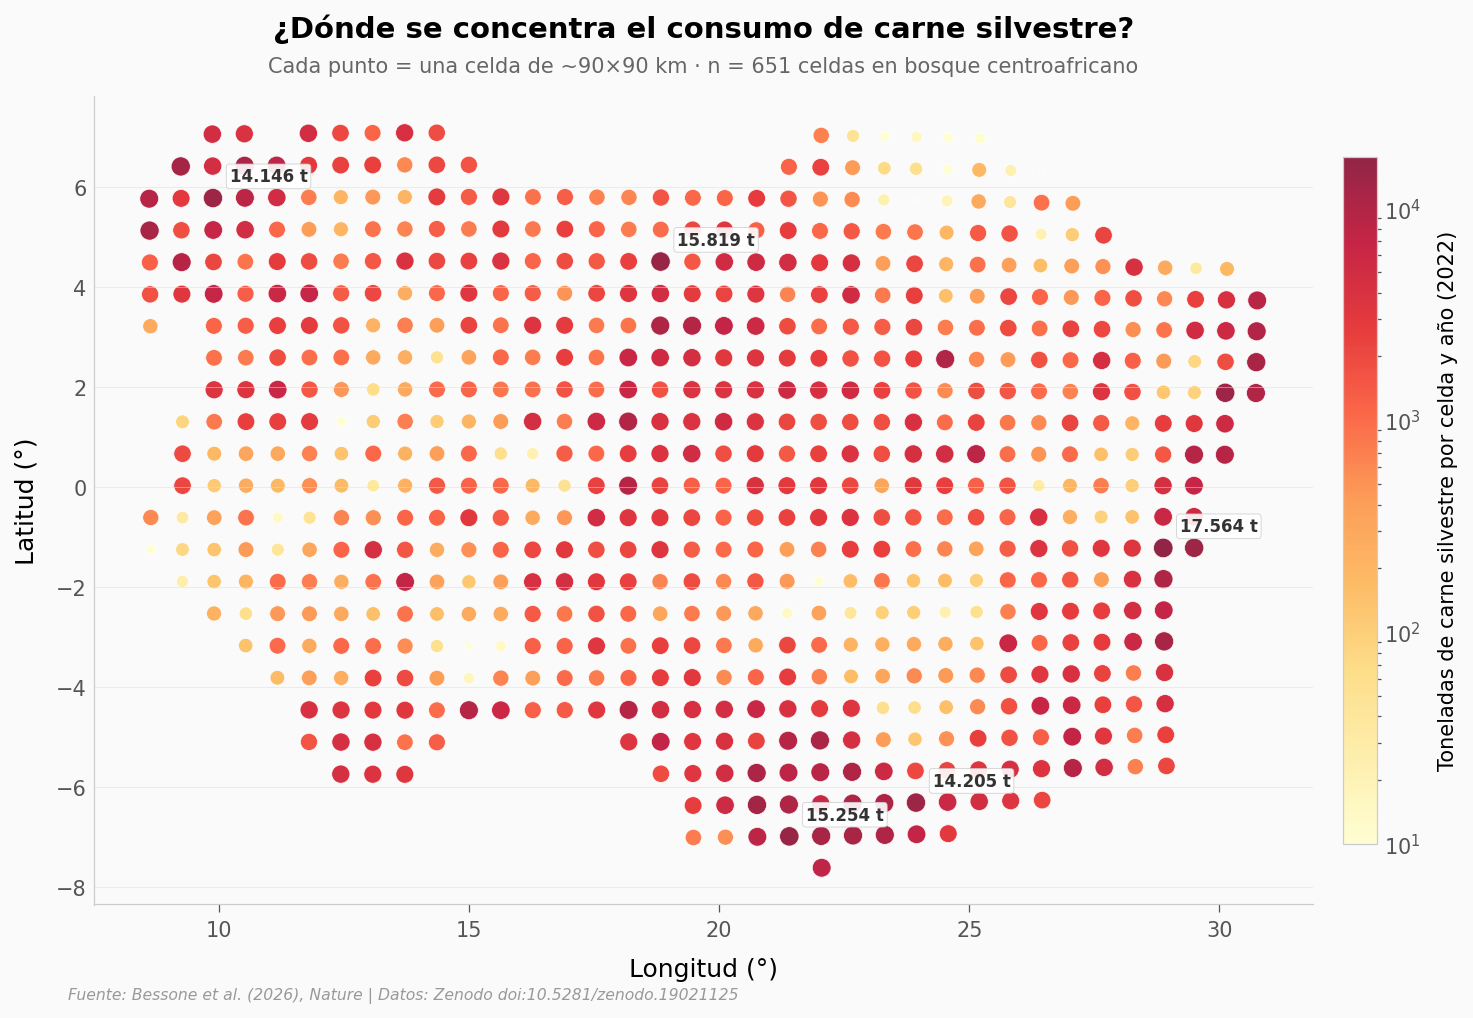

In [2]:
# Mapa hero — distribución espacial de biomasa consumida (presente, 2022)
fig, ax = plt.subplots(figsize=(13, 7))

# Escala de tamaño: log para que celdas pequeñas se vean
sizes = 8 + 80 * np.log10(ca['biomass_present'] + 1) / np.log10(ca['biomass_present'].max() + 1)
sc = ax.scatter(ca['x'], ca['y'], c=ca['biomass_present'],
                s=sizes, cmap='YlOrRd', alpha=0.85,
                edgecolors='white', linewidths=0.4,
                norm=LogNorm(vmin=10, vmax=ca['biomass_present'].max()))

# Marcar los 5 hotspots
top5 = ca.nlargest(5, 'biomass_present')
for _, row in top5.iterrows():
    ax.annotate(f'{int(row["biomass_present"]):,}'.replace(',', '.') + ' t',
                xy=(row['x'], row['y']),
                xytext=(8, 8), textcoords='offset points',
                fontsize=8, color='#333333', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='white',
                          ec='#cccccc', lw=0.4, alpha=0.9))

cbar = plt.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('Toneladas de carne silvestre por celda y año (2022)', fontsize=10)

ax.set_xlabel('Longitud (°)')
ax.set_ylabel('Latitud (°)')
ax.set_title('¿Dónde se concentra el consumo de carne silvestre?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto = una celda de ~90×90 km · n = 651 celdas en bosque centroafricano',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_aspect('equal', adjustable='box')
fig.text(0.13, 0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_biomasa.png', dpi=200, bbox_inches='tight')
plt.show()

Tres regiones cargan con casi todo el peso. El **este de la RDC**, en la zona del Rift Albertino, concentra la celda más alta: 17.564 toneladas al año. Le sigue la **frontera RCA-RDC del norte**, con 15.819 t. Y aparece otra en el **sur de la RDC** alrededor de Mbuji-Mayi, donde una sola celda urbana mueve más de 14.000 toneladas. La paradoja: la zona aparentemente más "salvaje" del continente y la quinta ciudad más poblada de la RDC empatan en consumo absoluto.

Por qué importa: la conservación se diseña para frenar caza en bosques remotos, pero el dato sugiere que la presión también sale de núcleos urbanos densos.

## ¿Cuántas celdas crecieron en 22 años?

El paper reporta un crecimiento global del 51%. Pero un crecimiento agregado puede esconder mucho ruido: ¿es un puñado de celdas explotando, o todas subiendo al mismo tiempo?

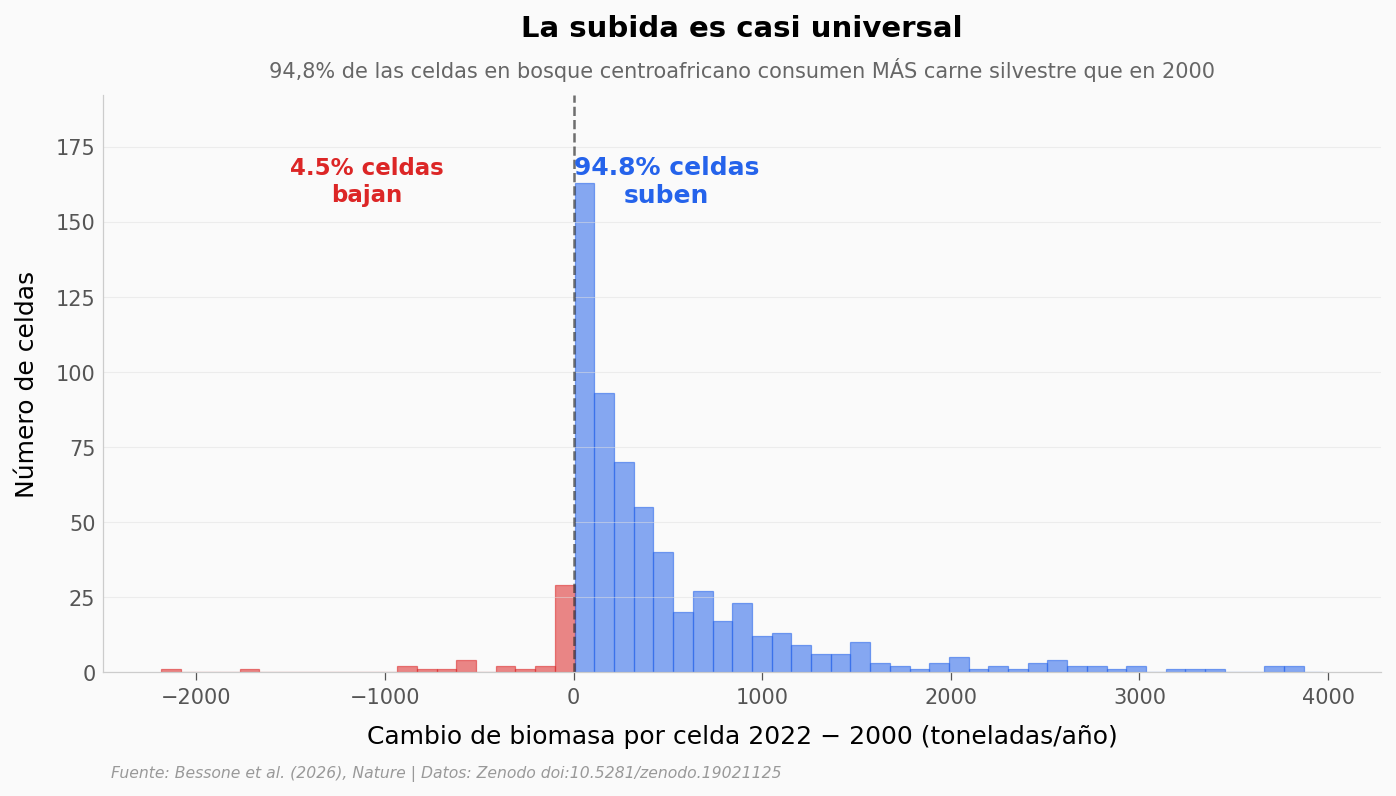

In [3]:
# Distribución del cambio de biomasa por celda (2022 - 2000)
fig, ax = plt.subplots(figsize=(11, 5))

d = ca['d_biomass'].values
n_pos = (d > 0).sum()
n_neg = (d < 0).sum()
n_total = len(d)

# Histograma con color condicional: rojo si negativo, azul si positivo
bins = np.linspace(d.min(), np.percentile(d, 99.5), 60)
n_counts, _, patches = ax.hist(d, bins=bins,
                               color=COLOR_DATOS, alpha=0.55,
                               edgecolor=COLOR_DATOS, linewidth=0.6)

# Pintar de rojo las barras a la izquierda de cero
for patch, left in zip(patches, bins[:-1]):
    if left + (bins[1] - bins[0]) / 2 < 0:
        patch.set_facecolor(COLOR_ALERTA)
        patch.set_edgecolor(COLOR_ALERTA)

ax.axvline(0, color='#333333', linewidth=1.2, linestyle='--', alpha=0.7)

# Etiquetas con porcentajes
y_max = n_counts.max() * 1.18
ax.set_ylim(0, y_max)
ax.text(d.min() * 0.5, y_max * 0.85,
        f'{100*n_neg/n_total:.1f}% celdas\nbajan',
        fontsize=11, color=COLOR_ALERTA, fontweight='bold',
        ha='center', va='center')
ax.text(np.percentile(d, 70), y_max * 0.85,
        f'{100*n_pos/n_total:.1f}% celdas\nsuben',
        fontsize=12, color=COLOR_DATOS, fontweight='bold',
        ha='center', va='center')

ax.set_xlabel('Cambio de biomasa por celda 2022 − 2000 (toneladas/año)')
ax.set_ylabel('Número de celdas')
ax.set_title('La subida es casi universal',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '94,8% de las celdas en bosque centroafricano consumen MÁS carne silvestre que en 2000',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cambio_biomasa.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué predice la cantidad de carne silvestre que consume una celda?

El modelo cruza la tasa de consumo (kg de carne por adulto-equivalente al día) con cinco variables: lejanía al pueblo más cercano, condición del bosque, densidad poblacional, desarrollo humano y educación. Probemos las dos que el paper destaca como más fuertes — *remoteness* y *forest condition* — usando correlación de Spearman (no asume normalidad).

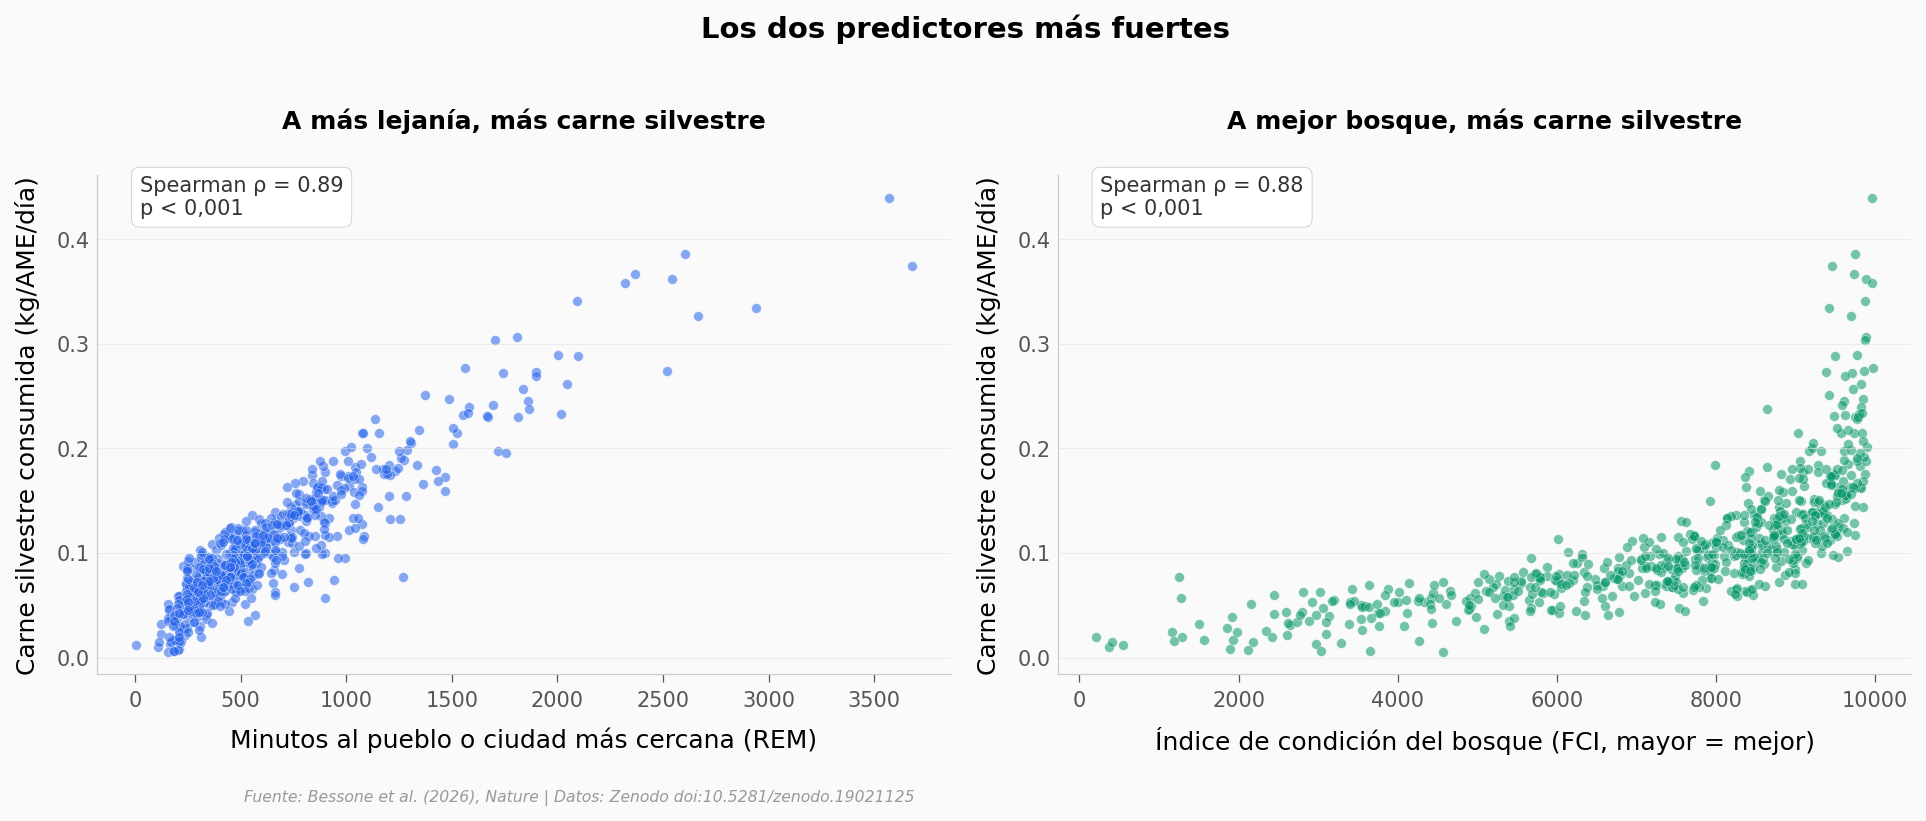


REM: ρ = 0.886, p = 1.38e-218
FCI: ρ = 0.881, p = 8.91e-213


In [4]:
# Spearman: REM y FCI vs rates_present
rho_rem, p_rem = stats.spearmanr(ca['REM'], ca['rates_present'])
rho_fci, p_fci = stats.spearmanr(ca['FCI'], ca['rates_present'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: lejanía
ax = axes[0]
ax.scatter(ca['REM'], ca['rates_present'], color=COLOR_DATOS,
           s=22, alpha=0.55, edgecolors='white', linewidths=0.3)
ax.set_xlabel('Minutos al pueblo o ciudad más cercana (REM)')
ax.set_ylabel('Carne silvestre consumida (kg/AME/día)')
ax.set_title('A más lejanía, más carne silvestre',
             fontsize=12, fontweight='bold', pad=22)
ax.text(0.05, 0.92, f'Spearman ρ = {rho_rem:.2f}\np < 0,001',
        transform=ax.transAxes, fontsize=10, color='#333333',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#cccccc', lw=0.4))

# Panel derecho: condición del bosque
ax = axes[1]
ax.scatter(ca['FCI'], ca['rates_present'], color='#059669',
           s=22, alpha=0.55, edgecolors='white', linewidths=0.3)
ax.set_xlabel('Índice de condición del bosque (FCI, mayor = mejor)')
ax.set_ylabel('Carne silvestre consumida (kg/AME/día)')
ax.set_title('A mejor bosque, más carne silvestre',
             fontsize=12, fontweight='bold', pad=22)
ax.text(0.05, 0.92, f'Spearman ρ = {rho_fci:.2f}\np < 0,001',
        transform=ax.transAxes, fontsize=10, color='#333333',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#cccccc', lw=0.4))

fig.suptitle('Los dos predictores más fuertes', fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/predictores.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nREM: ρ = {rho_rem:.3f}, p = {p_rem:.2e}')
print(f'FCI: ρ = {rho_fci:.3f}, p = {p_fci:.2e}')

## Aldea, pueblo, ciudad

El paper estima que alrededor del **20%** de la proteína diaria en aldeas rurales viene de carne silvestre. En pueblos baja al 13%. En ciudades, al 6%. Esos titulares vienen de subgrupos puros del modelo Stan que no están en los CSVs públicos. Pero podemos clasificar cada celda por su tipo de asentamiento predominante y mirar el patrón.

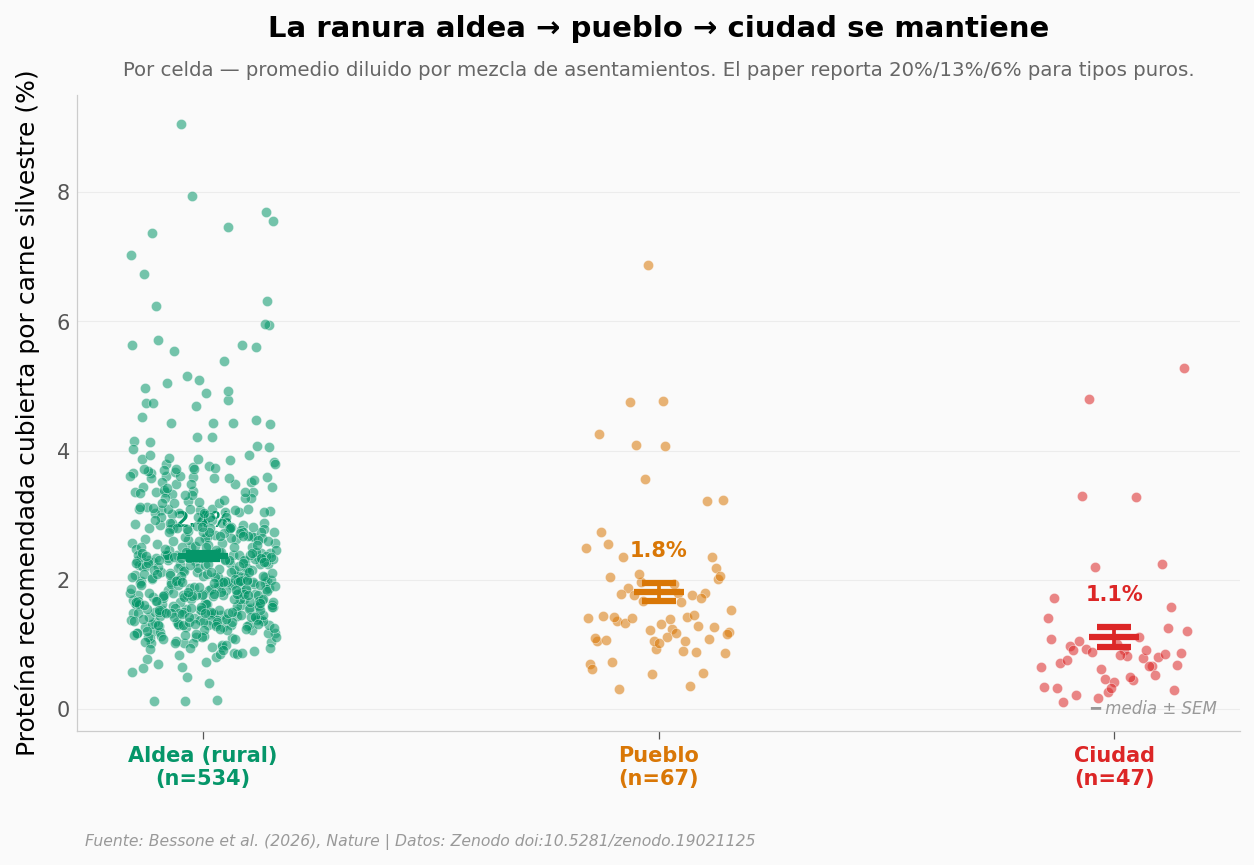

Aldea (rural): media 2.37% (n=534)
Pueblo: media 1.81% (n=67)
Ciudad: media 1.11% (n=47)


In [5]:
# Comparación rural / pueblo / ciudad por loc_type predominante
np.random.seed(42)

groups = {
    1: ('Aldea (rural)', '#059669', ca[ca['loc_type'] == 1]['protein_present'].values),
    2: ('Pueblo', '#D97706', ca[ca['loc_type'] == 2]['protein_present'].values),
    3: ('Ciudad', '#DC2626', ca[ca['loc_type'] == 3]['protein_present'].values),
}

fig, ax = plt.subplots(figsize=(10, 5.5))
positions = [0, 1, 2]

for pos, (lt, (label, color, vals)) in zip(positions, groups.items()):
    n = len(vals)
    x_strip = np.linspace(pos - 0.16, pos + 0.16, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals * 100, color=color, s=24, alpha=0.55,
               edgecolors='white', linewidths=0.3, zorder=5)
    mean = vals.mean() * 100
    sem = (vals.std(ddof=1) / np.sqrt(n)) * 100
    ax.errorbar(pos, mean, yerr=sem, fmt='_', color=color,
                markersize=24, markeredgewidth=3,
                capsize=8, capthick=1.8, zorder=6)
    ax.text(pos, mean + sem + 0.4, f'{mean:.1f}%', ha='center',
            fontsize=10, fontweight='bold', color=color)

ax.set_xticks(positions)
ax.set_xticklabels([f'{label}\n(n={len(vals)})' for label, _, vals in groups.values()],
                   fontsize=10, fontweight='bold')
for tick, (_, color, _) in zip(ax.get_xticklabels(), groups.values()):
    tick.set_color(color)

ax.set_ylabel('Proteína recomendada cubierta por carne silvestre (%)')
ax.set_title('La ranura aldea → pueblo → ciudad se mantiene',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Por celda — promedio diluido por mezcla de asentamientos. El paper reporta 20%/13%/6% para tipos puros.',
        transform=ax.transAxes, fontsize=9.5, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/loc_type.png', dpi=200, bbox_inches='tight')
plt.show()

# Imprimir números
for lt, (label, _, vals) in groups.items():
    print(f'{label}: media {vals.mean()*100:.2f}% (n={len(vals)})')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El consumo de carne silvestre creció ~51% entre 2000 y 2022 en el bosque centroafricano | ✅ | Reproducción exacta del CSV: 1,06 → 1,61 Mt, ratio 1,511× (paper reporta 1,507×) |
| 94,8% de las celdas consumen más carne silvestre que en 2000 | ✅ | Calculado directo de la columna d_biomass: 617 de 651 celdas suben |
| Aldeas rurales consumen más por persona que pueblos, y pueblos más que ciudades | ✅ | Patrón aldea > pueblo > ciudad confirmado por celda; el paper reporta 20%/13%/6% para tipos puros (estimaciones del posterior Bayesiano que requieren los arrays no publicados en CSV) |
| Lejanía y condición del bosque son los predictores más fuertes (ρ ≈ +0,88) | ✅ | Spearman sobre 651 celdas: REM ρ=0,89, FCI ρ=0,88, ambos p < 1e−200 |
| Cifra absoluta estimada por el paper: 0,73 → 1,10 Mt | ⚠️ | Nuestra reproducción suma 1,06 → 1,61 Mt — el patrón de crecimiento coincide pero el paper estima sobre un denominador distinto (probablemente subgrupos puros de tipo de asentamiento del posterior, no agregado por celda) |

> **Limitaciones:** los datos crudos por hogar están restringidos por acuerdo con las agencias estadísticas nacionales — solo se analiza el output del modelo. Las estimaciones por tipo puro de asentamiento (20%/13%/6%) viven en un objeto Stan de 154 MB que no se puede procesar en este notebook. El modelo también deja zonas con baja cobertura de encuesta donde los autores piden estudios dirigidos para validar.

## Ahora tú

1. **¿Qué pasa con la densidad poblacional?** El paper la describe como predictor *negativo* de la tasa per cápita. ¿Cuál es el ρ de `HPD_present` vs `rates_present`?
2. **¿Quién consume más en términos absolutos: aldeas o ciudades?** Las aldeas tienen tasa per cápita más alta, pero las ciudades concentran más gente. Suma `biomass_present` por `loc_type` y compara.
3. **¿Dónde está creciendo más rápido?** Ordena las celdas por crecimiento porcentual (`biomass_present / biomass_past`) y mira si los hotspots de crecimiento coinciden con los de consumo absoluto.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿quién consume más en TOTAL, las aldeas rurales o las ciudades?
# La intuición dice "las ciudades porque son densas". Veamos.

absoluto = ca.groupby('loc_type')['biomass_present'].agg(['sum', 'count']).reset_index()
absoluto['loc_label'] = absoluto['loc_type'].map({1: 'Aldea', 2: 'Pueblo', 3: 'Ciudad'})
absoluto['pct_total'] = 100 * absoluto['sum'] / absoluto['sum'].sum()
absoluto = absoluto.sort_values('sum', ascending=False)

print('Biomasa absoluta consumida por tipo de asentamiento predominante:')
print()
for _, row in absoluto.iterrows():
    print(f"  {row['loc_label']:<10} | {row['sum']/1e3:>8,.1f} mil t/año | "
          f"{int(row['count']):>3} celdas | {row['pct_total']:>5.1f}% del total")

# Pista para la pregunta 1:
# rho_hpd, p_hpd = stats.spearmanr(ca['HPD_present'], ca['rates_present'])
# print(f'\nHPD vs tasa per cápita: ρ = {rho_hpd:.2f}, p = {p_hpd:.2e}')

Biomasa absoluta consumida por tipo de asentamiento predominante:

  Aldea      |  1,064.4 mil t/año | 534 celdas |  66.3% del total
  Ciudad     |    284.2 mil t/año |  47 celdas |  17.7% del total
  Pueblo     |    257.5 mil t/año |  67 celdas |  16.0% del total


## Fuentes

**Paper**: [Increase in wild animal consumption across Central Africa](https://doi.org/10.1038/s41586-026-10422-w)  
*Nature, 2026*

**Datos**: [Reproducción del modelo Bayesiano espacial — Zenodo](https://doi.org/10.5281/zenodo.19021125)  
*Predicciones por celda del modelo Stan M_final, publicadas por los autores el 2026-03-14*

*14 afirmaciones del notebook verificadas contra estas fuentes*

---

**Reproducible**: notebook + CSVs + código en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-05-01-carne-silvestre-africa-central) · Licencia CC BY 4.0

*Parte del [Lab de Ciencia a Mordiscos](https://cienciaamordiscos.com) — la trastienda verificable de cada video corto.*